# EDA ECOMMERCE CHURN
## NOMBRE: CÉSAR MAYTA
## FUENTE : https://www.kaggle.com/datasets/upam22/ecommerce-customer-churn-data

In [133]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [134]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("upam22/ecommerce-customer-churn-data")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'ecommerce-customer-churn-data' dataset.
Path to dataset files: /kaggle/input/ecommerce-customer-churn-data


In [135]:
!ls /root/.cache/kagglehub/datasets/upam22/ecommerce-customer-churn-data/versions/1

ecom_data.csv


In [136]:
%run '/content/pandas_missing_extension.ipynb'

In [137]:
data_df = pd.read_csv('/root/.cache/kagglehub/datasets/upam22/ecommerce-customer-churn-data/versions/1/ecom_data.csv')
data_df

,CustomerID,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
0,50001,1,4.0,Mobile Phone,3,6.0,Debit Card,Female,3.0,3,Laptop & Accessory,2,Single,9,1,11.0,1.0,1.0,5.0,160
1,50002,1,NaN,Phone,1,8.0,UPI,Male,3.0,4,Mobile,3,Single,7,1,15.0,0.0,1.0,0.0,121
2,50003,1,NaN,Phone,1,30.0,Debit Card,Male,2.0,4,Mobile,3,Single,6,1,14.0,0.0,1.0,3.0,120
3,50004,1,0.0,Phone,3,15.0,Debit Card,Male,2.0,4,Laptop & Accessory,5,Single,8,0,23.0,0.0,1.0,3.0,134
4,50005,1,0.0,Phone,1,12.0,CC,Male,NaN,3,Mobile,5,Single,3,0,11.0,1.0,1.0,3.0,130
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5625,55626,0,10.0,Computer,1,30.0,Credit Card,Male,3.0,2,Laptop & Accessory,1,Married,6,0,18.0,1.0,2.0,4.0,151
5626,55627,0,13.0,Mobile Phone,1,13.0,Credit Card,Male,3.0,5,Fashion,5,Married,6,0,16.0,1.0,2.0,NaN,225
5627,55628,0,1.0,Mobile Phone,1,11.0,Debit Card,Male,3.0,2,Laptop & Accessory,4,Married,3,1,21.0,1.0,2.0,4.0,186
5628,55629,0,23.0,Computer,3,9.0,Credit Card,Male,4.0,5,Laptop & Accessory,4,Married,4,0,15.0,2.0,2.0,9.0,179


# EDA

In [138]:
data_df.dtypes

,0
CustomerID,int64
Churn,int64
Tenure,float64
PreferredLoginDevice,object
CityTier,int64
WarehouseToHome,float64
PreferredPaymentMode,object
Gender,object
HourSpendOnApp,float64
NumberOfDeviceRegistered,int64


In [139]:
data_df.dtypes.value_counts()

,count
int64,8
float64,7
object,5


# TRATAMIENTO DE NULOS

In [140]:
data_df = data_df.drop('OrderCount',axis=1)

In [141]:
data_df.missing.number_missing()

np.int64(1598)

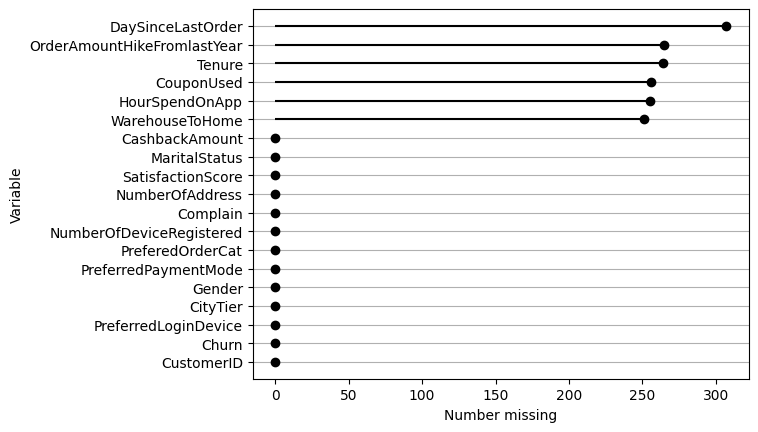

In [142]:
data_df.missing.missing_variable_plot()

# IMPUTACIÓN DE VARIABLES NÚMERICAS

In [143]:
data_df.columns

Index(['CustomerID', 'Churn', 'Tenure', 'PreferredLoginDevice', 'CityTier',
       'WarehouseToHome', 'PreferredPaymentMode', 'Gender', 'HourSpendOnApp',
       'NumberOfDeviceRegistered', 'PreferedOrderCat', 'SatisfactionScore',
       'MaritalStatus', 'NumberOfAddress', 'Complain',
       'OrderAmountHikeFromlastYear', 'CouponUsed', 'DaySinceLastOrder',
       'CashbackAmount'],
      dtype='object')

In [144]:
numerics_nan = ['DaySinceLastOrder','OrderAmountHikeFromlastYear','Tenure','CouponUsed','HourSpendOnApp','WarehouseToHome']

In [145]:
df_cleaned = data_df.copy()

In [146]:
for variable in numerics_nan:
  df_cleaned[variable] = df_cleaned[variable].fillna(float(round(df_cleaned[variable].mean())))

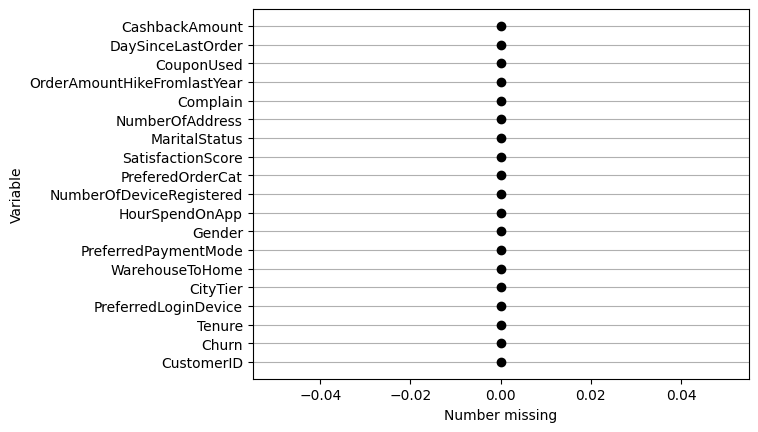

In [147]:
df_cleaned.missing.missing_variable_plot()

In [148]:
data_df = df_cleaned

In [149]:
data_df.shape

(5630, 19)

In [150]:
import re

def to_snake_case(name):
    # Insert an underscore before any uppercase letter that is not at the start of the string
    name = re.sub(r'(?<!^)(?=[A-Z])', '_', name)
    return name.lower()

data_df.columns = [to_snake_case(col) for col in data_df.columns]

In [151]:
data_df

,customer_i_d,churn,tenure,preferred_login_device,city_tier,warehouse_to_home,preferred_payment_mode,gender,hour_spend_on_app,number_of_device_registered,prefered_order_cat,satisfaction_score,marital_status,number_of_address,complain,order_amount_hike_fromlast_year,coupon_used,day_since_last_order,cashback_amount
0,50001,1,4.0,Mobile Phone,3,6.0,Debit Card,Female,3.0,3,Laptop & Accessory,2,Single,9,1,11.0,1.0,5.0,160
1,50002,1,10.0,Phone,1,8.0,UPI,Male,3.0,4,Mobile,3,Single,7,1,15.0,0.0,0.0,121
2,50003,1,10.0,Phone,1,30.0,Debit Card,Male,2.0,4,Mobile,3,Single,6,1,14.0,0.0,3.0,120
3,50004,1,0.0,Phone,3,15.0,Debit Card,Male,2.0,4,Laptop & Accessory,5,Single,8,0,23.0,0.0,3.0,134
4,50005,1,0.0,Phone,1,12.0,CC,Male,3.0,3,Mobile,5,Single,3,0,11.0,1.0,3.0,130
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5625,55626,0,10.0,Computer,1,30.0,Credit Card,Male,3.0,2,Laptop & Accessory,1,Married,6,0,18.0,1.0,4.0,151
5626,55627,0,13.0,Mobile Phone,1,13.0,Credit Card,Male,3.0,5,Fashion,5,Married,6,0,16.0,1.0,5.0,225
5627,55628,0,1.0,Mobile Phone,1,11.0,Debit Card,Male,3.0,2,Laptop & Accessory,4,Married,3,1,21.0,1.0,4.0,186
5628,55629,0,23.0,Computer,3,9.0,Credit Card,Male,4.0,5,Laptop & Accessory,4,Married,4,0,15.0,2.0,9.0,179


# CONTEOS Y PROPORCIONES

In [152]:
df_clean = data_df

In [153]:
df_clean = data_df.drop('customer_i_d', axis=1)

In [154]:
df_clean.describe()

,churn,tenure,city_tier,warehouse_to_home,hour_spend_on_app,number_of_device_registered,satisfaction_score,number_of_address,complain,order_amount_hike_fromlast_year,coupon_used,day_since_last_order,cashback_amount
count,5630.000000,5630.000000,5630.000000,5630.000000,5630.000000,5630.000000,5630.000000,5630.000000,5630.000000,5630.000000,5630.000000,5630.000000,5630.000000
mean,0.168384,10.180995,1.654707,15.655950,2.934636,3.688988,3.066785,4.214032,0.284902,15.721670,1.762345,4.568384,177.221492
std,0.374240,8.354261,0.915389,8.339426,0.705528,1.023999,1.380194,2.583586,0.451408,3.588459,1.851764,3.554893,49.193869
min,0.000000,0.000000,1.000000,5.000000,0.000000,1.000000,1.000000,1.000000,0.000000,11.000000,0.000000,0.000000,0.000000
25%,0.000000,3.000000,1.000000,9.000000,2.000000,3.000000,2.000000,2.000000,0.000000,13.000000,1.000000,2.000000,146.000000
50%,0.000000,9.000000,1.000000,14.000000,3.000000,4.000000,3.000000,3.000000,0.000000,15.000000,1.000000,4.000000,163.000000
75%,0.000000,15.000000,3.000000,20.000000,3.000000,4.000000,4.000000,6.000000,1.000000,18.000000,2.000000,7.000000,196.000000
max,1.000000,61.000000,3.000000,127.000000,5.000000,6.000000,5.000000,22.000000,1.000000,26.000000,16.000000,46.000000,325.000000


In [155]:
df_clean.describe(include=object)

,preferred_login_device,preferred_payment_mode,gender,prefered_order_cat,marital_status
count,5630,5630,5630,5630,5630
unique,3,7,2,6,3
top,Mobile Phone,Debit Card,Male,Laptop & Accessory,Married
freq,2765,2314,3384,2050,2986


# ANALISIS UNIVARIADO

In [156]:
variable = 'cashback_amount'
data = df_clean[variable]

# MEDIDAS DE TENDENCIA CENTRAL

In [157]:
mean_val = data.mean()
median_val = data.median()
mode_val = data.mode()[0]

print(f"📊 Medidas de tendencia central de {variable}")
print(f"Media (μ): {mean_val:.2f}")
print(f"Mediana: {median_val:.2f}")
print(f"Moda: {mode_val:.2f}")

📊 Medidas de tendencia central de cashback_amount
Media (μ): 177.22
Mediana: 163.00
Moda: 148.00


# MEDIDAS DE DISPERSIÓN

In [158]:
variance_val = data.var()
std_val = data.std()
range_val = data.max() - data.min()
q1 = data.quantile(0.25)
q3 = data.quantile(0.75)
iqr = q3 - q1

print(f"\n📈 Medidas de dispersión de {variable}")
print(f"Varianza (σ²): {variance_val:.2f}")
print(f"Desviación estándar (σ): {std_val:.2f}")
print(f"Rango: {range_val:.2f}")
print(f"Rango intercuartílico (IQR): {iqr:.2f}")


📈 Medidas de dispersión de cashback_amount
Varianza (σ²): 2420.04
Desviación estándar (σ): 49.19
Rango: 325.00
Rango intercuartílico (IQR): 50.00


In [159]:
limite_inferior = q1 - 1.5 * iqr
limite_superior = q3 + 1.5 * iqr

outliers = data[(data < limite_inferior) | (data > limite_superior)]

print(f"\n⚠️ Detección de Outliers (Regla del IQR) para {variable}")
print(f"Límite inferior: {limite_inferior:.2f}")
print(f"Límite superior: {limite_superior:.2f}")
print(f"Número de outliers detectados: {len(outliers)}")


⚠️ Detección de Outliers (Regla del IQR) para cashback_amount
Límite inferior: 71.00
Límite superior: 271.00
Número de outliers detectados: 447


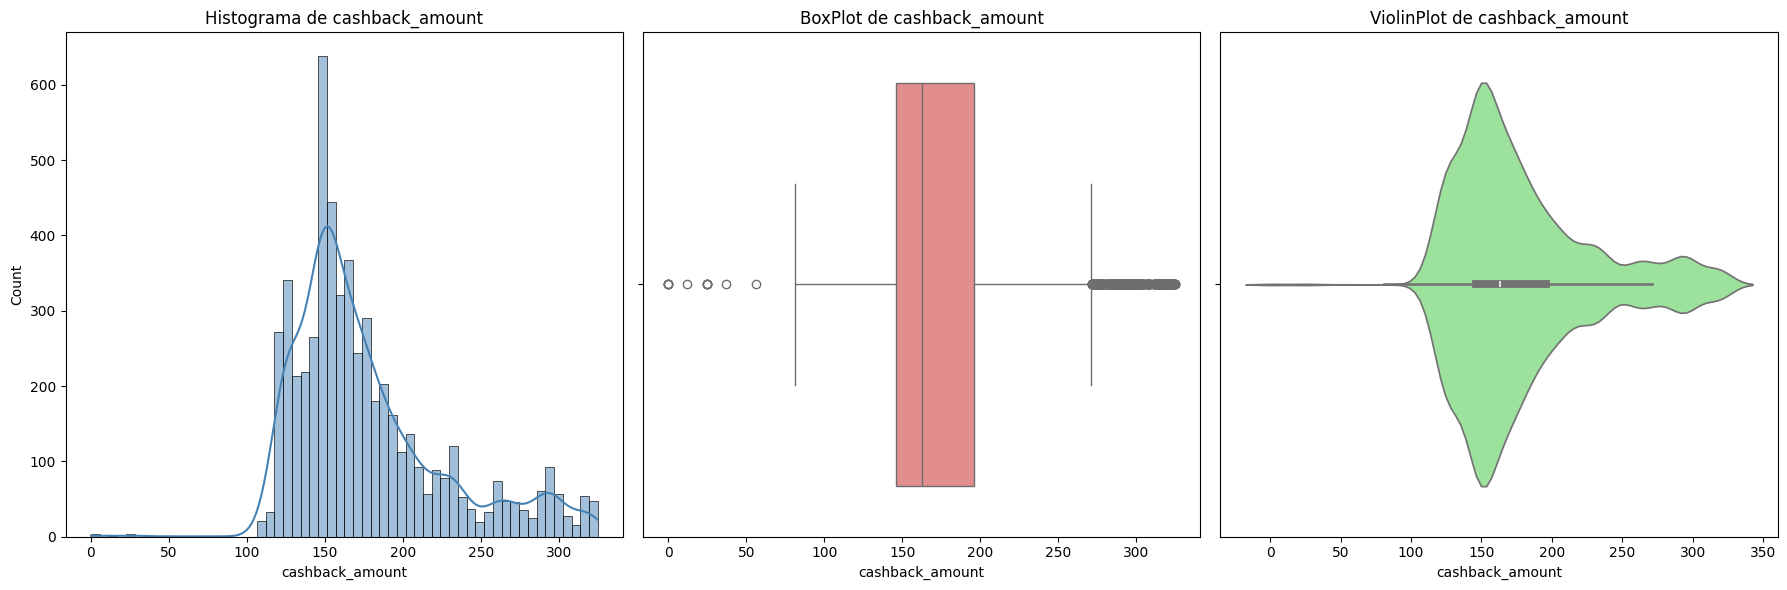

In [160]:
fig,axes = plt.subplots(1,3,figsize=(18,6))

#histograma
sns.histplot(data,kde=True,color='steelblue',ax=axes[0])
axes[0].set_title(f'Histograma de {variable}')

#boxplot
sns.boxplot(x=data,color='lightcoral',ax=axes[1])
axes[1].set_title(f'BoxPlot de {variable}')

#violinplot
sns.violinplot(x=data,color='lightgreen',ax=axes[2])
axes[2].set_title(f'ViolinPlot de {variable}')

plt.tight_layout()
plt.show()

# ELIMINAR OUTLIERS

In [161]:
def remove_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]

In [162]:
df_clean = remove_outliers(df_clean,variable)
data = df_clean[variable]

# CODIFICACIÓN DE VARIABLES CATEGORICAS

In [163]:
df_clean.dtypes

,0
churn,int64
tenure,float64
preferred_login_device,object
city_tier,int64
warehouse_to_home,float64
preferred_payment_mode,object
gender,object
hour_spend_on_app,float64
number_of_device_registered,int64
prefered_order_cat,object


In [164]:
df_clean

,churn,tenure,preferred_login_device,city_tier,warehouse_to_home,preferred_payment_mode,gender,hour_spend_on_app,number_of_device_registered,prefered_order_cat,satisfaction_score,marital_status,number_of_address,complain,order_amount_hike_fromlast_year,coupon_used,day_since_last_order,cashback_amount
0,1,4.0,Mobile Phone,3,6.0,Debit Card,Female,3.0,3,Laptop & Accessory,2,Single,9,1,11.0,1.0,5.0,160
1,1,10.0,Phone,1,8.0,UPI,Male,3.0,4,Mobile,3,Single,7,1,15.0,0.0,0.0,121
2,1,10.0,Phone,1,30.0,Debit Card,Male,2.0,4,Mobile,3,Single,6,1,14.0,0.0,3.0,120
3,1,0.0,Phone,3,15.0,Debit Card,Male,2.0,4,Laptop & Accessory,5,Single,8,0,23.0,0.0,3.0,134
4,1,0.0,Phone,1,12.0,CC,Male,3.0,3,Mobile,5,Single,3,0,11.0,1.0,3.0,130
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5625,0,10.0,Computer,1,30.0,Credit Card,Male,3.0,2,Laptop & Accessory,1,Married,6,0,18.0,1.0,4.0,151
5626,0,13.0,Mobile Phone,1,13.0,Credit Card,Male,3.0,5,Fashion,5,Married,6,0,16.0,1.0,5.0,225
5627,0,1.0,Mobile Phone,1,11.0,Debit Card,Male,3.0,2,Laptop & Accessory,4,Married,3,1,21.0,1.0,4.0,186
5628,0,23.0,Computer,3,9.0,Credit Card,Male,4.0,5,Laptop & Accessory,4,Married,4,0,15.0,2.0,9.0,179


In [165]:
df_clean.to_csv('ecom_churn_cleaned.csv',index=None)